# Decision Trees
In this notebook, we will examine yet another classification technique: Decision Trees.

**Learning Outcomes**

1. Describe how a decision tree classifier is constructed and identify its parameters
2. Implement a decision tree classification model with the `scikit-learn` package

**Import modules**

Begin by importing the modules to be used in this notebook

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import classifier_helper_functions as hf
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

### Yet Another Classification Problem
In this notebook, we will revisit the water mass classification problem introducted in the KNN notebook. As a reminder, we are looking to classify watermass in the ocean based on the following data set which we will read in and process as before:

In [2]:
df = pd.read_csv(os.path.join('..','data','water_mass_samples.csv'))

watermasses = list(df['WaterMass'].unique())
watermasses_long = list(df['WaterMass_LongName'].unique())

mass_to_number = {}
for i in range(len(watermasses)):
    mass_to_number[watermasses[i]]=i

# Create the new column using map
df['WaterMassIndex'] = df['WaterMass'].map(mass_to_number)

Again, let's define a common set of bounds for our axes:

In [3]:
# define some bounds to be used in the plots below
min_S = 33.8
max_S = 37.2
min_T = -1
max_T = 18

Next, let's plot the data on a temperature-salinity diagram - an oceanographer's favorite diagram:

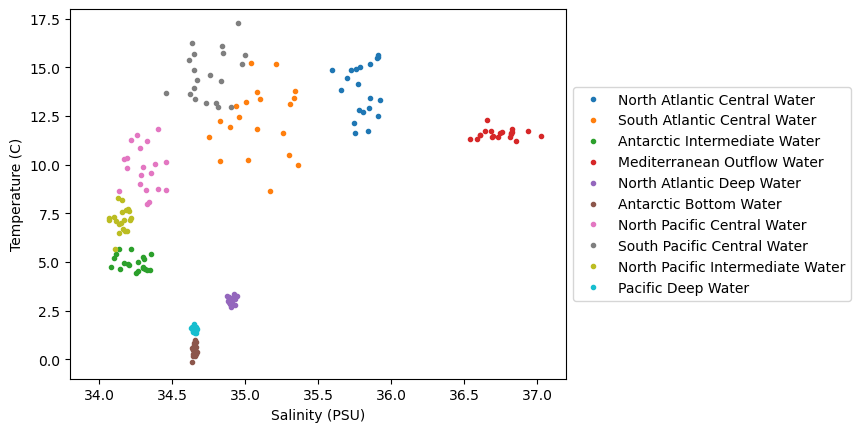

In [4]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for w, watermass, in enumerate(watermasses):
    plt.plot(df[df['WaterMass']==watermass]['Salinity_PSU'],
             df[df['WaterMass']==watermass]['Temperature_C'],
             '.', label=watermasses_long[w], color=colors[w])
plt.gca().set_xlim([min_S,max_S])
plt.gca().set_ylim([min_T,max_T])
plt.ylabel('Temperature (C)')
plt.xlabel('Salinity (PSU)')
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

We can see in this dataset that there is are some clusters of points in these diagrams, but they are not all unique - there are some overlapping sections. Let's see how we can go about classifying various parts of this diagram, even for unknown regions. 

## Decision Trees

The next classifier we'll look at is a *Decision Tree*. To consider how a desision tree works, let's consider differentiating some water masses using a simple rule. In the above diagram, we can see that one distinguishing feature of the Mediterranean Outflow Water (MOW) is that the salinity is above 36.25 psu. We can use this attribute to set up a simple classification according to the following diagram:

<img src="../images/Decision_Tree_Schematic_1layer.png" alt="Schematic of a 1-layer Decision Tree" width="500">

This simple classification allows us to distinguish between two different classes - but clearly we have 10 classes. So, how can we use other information about our classes? Well, we could consider adding another "branch" to this process by considering the temperature. From the above scatter plot we can see that the Antarctic Bottom Water (AABW) is separated from the other water masses by a temperature of 1 degree C. Using this information, we could add another branch as follows:

<img src="../images/Decision_Tree_Schematic_2layer.png" alt="Schematic of a 2-layer Decision Tree" width="500">

Using this same approach, you could image adding additional branches into the tree until all regions of the data set are classified appropriately.

Below, we'll explore how the splitting parameters (e.g. the 36.25 psu and the 1 degree C) are determined, but for now, let's see what the results of a decision tree look like for our example using `scikit-learn`'s implementation. Let's make a decision tree model and fit it to our normalized data:

In [5]:
dt = DecisionTreeClassifier(max_depth=10)
salt_normalized = (df['Salinity_PSU']-min_S)/(max_S-min_S)
temp_normalized = (df['Temperature_C']-min_T)/(max_T-min_T)
dt.fit(np.column_stack([salt_normalized,temp_normalized]), df['WaterMassIndex']);

Next, let's make a plot to classify the regions of our data space:

In [6]:
# make some arrays for plotting
salinity = np.linspace(min_S,max_S,100)
temperature = np.linspace(min_T,max_T,100)
Salinity, Temperature = np.meshgrid(salinity, temperature)

# normalize
salinity_norm = (salinity-min_S)/(max_S-min_S)
temperature_norm = (temperature-min_T)/(max_T-min_T)
Salinity_norm,Temperature_norm = np.meshgrid(salinity_norm ,temperature_norm)

# make predictions
WaterMassIndices = dt.predict(np.column_stack([Salinity_norm.ravel(),Temperature_norm.ravel()]))
WaterMassIndices = np.array(WaterMassIndices)
WaterMassIndices = WaterMassIndices.reshape(np.shape(Salinity_norm))

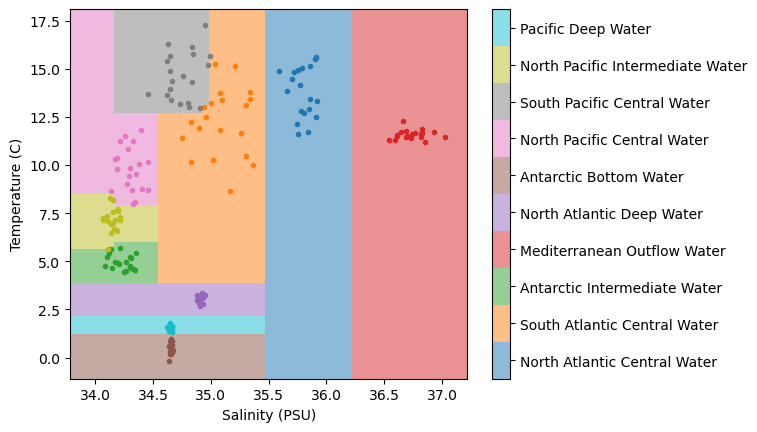

In [7]:
C = plt.pcolormesh(Salinity, Temperature, WaterMassIndices, cmap='tab10',
                   alpha=0.5, vmin=0, vmax=len(watermasses_long))
cbar = plt.colorbar(C, ticks=np.arange(len(watermasses_long))+0.5)
cbar.set_ticklabels(watermasses_long)
for w, watermass, in enumerate(watermasses):
    plt.plot(df[df['WaterMass']==watermass]['Salinity_PSU'],
             df[df['WaterMass']==watermass]['Temperature_C'],
             '.', label=watermass, color=colors[w])
plt.ylabel('Temperature (C)')
plt.xlabel('Salinity (PSU)')
plt.show()

In the above plot, we can see that we've classified the regions of our temperature-salinity space similar to the KNN example, but the results of the decision tree are a bit different. Specifically, we see that the boundaries are very "boxy" - and this isn't suprising because these regions are determined by a binary split based on two parameters. In practice, you would want to visualized your overall results with a few different classifiers and determine which approach is best suited to your example based on your domain-specific knowledge.

### Determining Splits

In the above example, we could clearly see that the MOW water mass, for example, is distinguished by a salinity of about 36.24 psu. But how exactly are these types of divisions determined in general? If we hope to have an algorithm that does this for us for a general data set, we're going to need a way to compute where these splits should happen. For our classification problem, we'll need a metric of what's typically termed the *impurity* of a data set, and another metric for the overall *information gain* resulting from a given parameter.

#### Gini Impurity

The impurity of a data set is a quantification of the mix of different classes in the set. A data set with all values having the same classification is "pure" and a very mixed class is "impure" (in the parlence of the field...). There are a few different metrics for "impurities" but one common one is the Gini Impurity, defined for a dataset $D$ as follows:

$$
I_G(D) = 1 - \sum_{i=1}^c p(i)^2
$$

where $p(i)$ is the proportion of points belonging to class $i$. When considering the whole data set for our MOW example, this would be computed as:

$$
I_G = 1 - \left( \frac{\text{number of points classified as MOW}}{\text{total number of points}} \right)^2 - \left( \frac{\text{number of points not classified as MOW}}{\text{total number of points}} \right)^2
$$

#### Information Gain
The concept of impurities is useful in defining the information gain, defined as

$$
G(D_p, f) = I(D_p) - \sum_{i=1}^m \frac{N_i}{N_p} I(D_i)
$$

where
- $D_p$ and $D_i$ are the "parent" and "child" datasets
- $f$ is the feature used to define the division
- $I$ is the impurity metric (e.g. the Gini impurity)
- $m$ is number of nodes (2 for a binary split)
- $N_p$ and $N_i$ are the number of points in the datasets $D_p$ and $D_i$ 

When considering our MOW dataset being split at a given salinity, this would be computed as

$$
G = I_{G,total} - \left( \frac{\text{number of points classified as MOW}}{\text{total number of points}} \right)I_{G,MOW} - \left( \frac{\text{number of points not classified as MOW}}{\text{total number of points}} \right)I_{G,not MOW}
$$

Let's code up this example for our particular data set:

In [8]:
# make a list of salt splits to explore
salt_splits = np.linspace(np.min(df['Salinity_PSU'])+0.01,
                          np.max(df['Salinity_PSU'])-0.01, 50)

# make empty arrays for the information gain and the impurities
information_gain = np.zeros_like(salt_splits)
gini_impurities = np.zeros_like(salt_splits)
gini_impurities_not_mow = np.zeros_like(salt_splits)
gini_impurities_mow = np.zeros_like(salt_splits)

# loop through each split to compute the quantities above
for s in range(len(salt_splits)):
    
    # divide the data set into two subsets based on the salt split
    subset_not_MOW = df[df['Salinity_PSU']<=salt_splits[s]]
    subset_MOW = df[df['Salinity_PSU']>salt_splits[s]]

    # compute the gini impurity for the not_MOW subset
    n_not_mow = len(subset_not_MOW)
    n_not_mow_in_not_mow = (subset_not_MOW['WaterMassIndex'] != 3).sum()
    n_mow_in_not_mow = (subset_not_MOW['WaterMassIndex'] == 3).sum()
    I_not_MOW = 1
    if n_not_mow>0:
        I_not_MOW -= ((n_not_mow_in_not_mow/n_not_mow))**2
        I_not_MOW -= ((n_mow_in_not_mow/n_not_mow))**2
    gini_impurities_not_mow[s] = I_not_MOW

    # compute the gini impurity for the MOW subset
    n_mow = len(subset_MOW)
    n_not_mow_in_mow = (subset_MOW['WaterMassIndex'] != 3).sum()
    n_mow_in_mow = (subset_MOW['WaterMassIndex'] == 3).sum()
    I_MOW = 1
    if n_mow>0:
        I_MOW -= ((n_not_mow_in_mow/n_mow))**2
        I_MOW -= ((n_mow_in_mow/n_mow))**2
    gini_impurities_mow[s] = I_MOW

    # compute the gini impurity for the whole dataset
    n = len(df)
    n_not_mow = (df['WaterMassIndex'] != 3).sum()
    n_mow = (df['WaterMassIndex'] == 3).sum()
    I = 1 - (n_mow/n)**2 - (n_not_mow/n)**2
    gini_impurities[s] = I

    # compute the information gain
    IG = I - (n_mow/n)*I_MOW - (n_not_mow/n)*I_not_MOW
    information_gain[s] = IG

With this information in hand, let's see how the quantities compare across our salinity space:

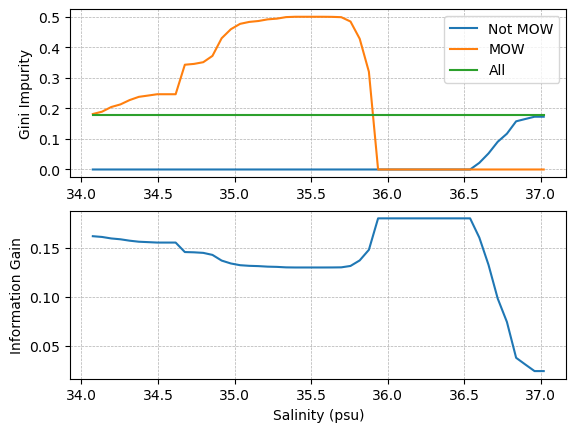

In [9]:
plt.subplot(2,1,1)
plt.plot(salt_splits, gini_impurities_not_mow, label='Not MOW')
plt.plot(salt_splits, gini_impurities_mow, label='MOW')
plt.plot(salt_splits, gini_impurities, label='All')
plt.ylabel('Gini Impurity')
plt.grid(linestyle='--', linewidth=0.5)
plt.legend()

plt.subplot(2,1,2)
plt.plot(salt_splits, information_gain)
plt.grid(linestyle='--', linewidth=0.5)
plt.ylabel('Information Gain')
plt.xlabel('Salinity (psu)')
plt.show()

As we can see in the plot above, the information gain is at its maximum when the salinity used to split the data set separates all of the points into the proper categories - i.e. the MOW subset only contains MOW points, and the not MOW set does not contain any MOW points. In this case, both subsets have a Gini Impurity of 0.

## Applying the model to the transect data

Now that we've created our decision tree model, let's see how the classifications look:

In [10]:
# read in the transect data
latitude, Z, depth, theta_grid, salt_grid = hf.read_ocean_transects(data_dir=os.path.join('..','data'))

# normalize the salinity and temperature grids
Salinity_norm = (salt_grid-min_S)/(max_S-min_S)
Temperature_norm = (theta_grid-min_T)/(max_T-min_T)

# estimate the water mass classifications using the DT classifier
WaterMassIndices_dt = dt.predict(np.column_stack([Salinity_norm.ravel(),Temperature_norm.ravel()]))
WaterMassIndices_dt = np.array(WaterMassIndices_dt)
WaterMassIndices_dt = WaterMassIndices_dt.reshape(np.shape(Salinity_norm))

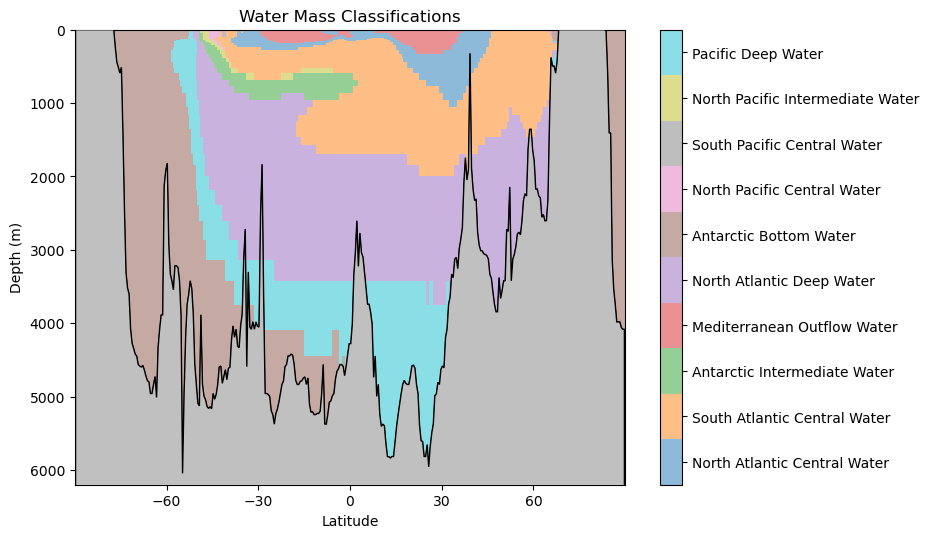

In [11]:
hf.plot_classification_crosssection(latitude, Z, depth, WaterMassIndices_dt, watermasses_long)    

As before, we should consider the following questions: what features do you observe in this classification? What aligns with your oceanographic expectations? Anything unusual?

### Comparing Decision Trees and $k$-Nearest Neighbors

In our previous notebook, we looked at the KNN classifier. Let's see how those results compare to our decision tree results:

In [12]:
# estimate the water mass classifications using the KNN classifier
X = df[['Salinity_PSU','Temperature_C']].to_numpy()
c = df['WaterMassIndex'].to_numpy()
salt_normalized = (df['Salinity_PSU']-min_S)/(max_S-min_S)
temp_normalized = (df['Temperature_C']-min_T)/(max_T-min_T)

# recreate the input data
X = np.column_stack([salt_normalized,temp_normalized])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, c);
WaterMassIndices_knn = knn.predict(np.column_stack([Salinity_norm.ravel(),Temperature_norm.ravel()]))
WaterMassIndices_knn = WaterMassIndices_knn.reshape(np.shape(Salinity_norm))

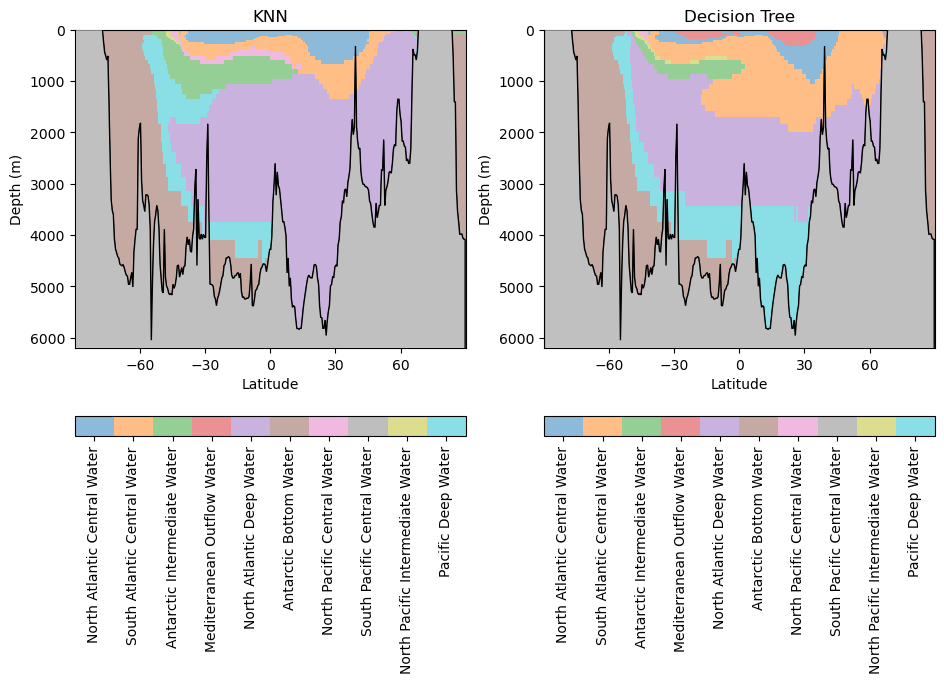

In [13]:
hf.plot_classification_crosssections(latitude, Z, depth, WaterMassIndices_knn, WaterMassIndices_dt, watermasses_long)  

What similarities and differences do you observe between these models?

**Key Takeaways**
1. Decision Tree classifiers assign classifications using a series of nested decision.
2. Like the KNN classifier, the model is able to make non-linear delineations of the feature space.